# Cross Validation in Python

## 1. Libraries and setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Helper functions

In [2]:
def summarize_class_balance(y, label_name="target"):
    counts = pd.Series(y, name=label_name).value_counts().sort_index()
    return pd.DataFrame({"class": counts.index, "count": counts.values, "percent": (counts.values / counts.values.sum() * 100).round(2)})


def plot_fold_scores(scores, title="Cross-validation scores", ylabel="Score"):
    folds = np.arange(1, len(scores) + 1)
    plt.figure(figsize=(8, 4.5))
    plt.bar(folds, scores)
    plt.axhline(np.mean(scores), linestyle="--", label=f"Mean = {np.mean(scores):.3f}")
    plt.title(title); plt.xlabel("Fold"); plt.ylabel(ylabel)
    plt.ylim(max(0, min(scores)-0.05), min(1, max(scores)+0.05))
    plt.legend(); plt.show()


def cv_summary(scores, label="Model"):
    return pd.DataFrame({"model": [label], "mean_score": [np.mean(scores)], "std_score": [np.std(scores)], "min_score": [np.min(scores)], "max_score": [np.max(scores)]}).round(3)

## 3. Simple toy dataset: why one split can be unstable

A single train-test split is useful, but it depends on one random partition of the data. The same model can receive different scores under different random splits.

In [3]:
X_toy, y_toy = make_classification(n_samples=120, n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=1, class_sep=0.9, flip_y=0.08, random_state=RANDOM_STATE)
toy_df = pd.DataFrame(X_toy, columns=["feature_1", "feature_2"])
toy_df["target"] = y_toy
toy_df.head()

,feature_1,feature_2,target
0,-0.750,0.020,0
1,0.907,0.435,1
2,0.983,1.598,1
3,1.382,1.717,1
4,0.268,-1.114,0


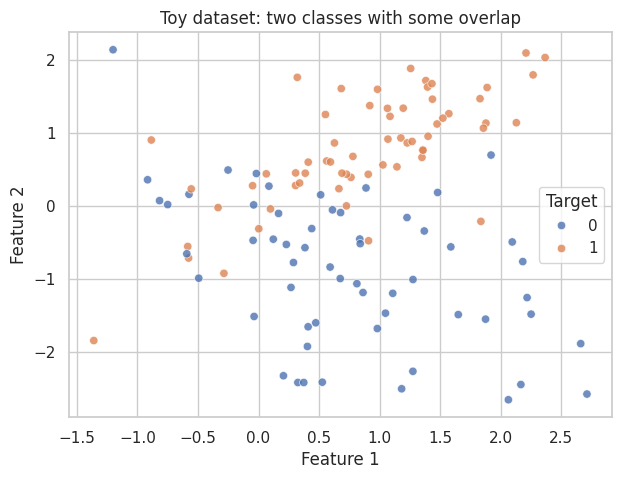

In [4]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=toy_df, x="feature_1", y="feature_2", hue="target", alpha=0.8)
plt.title("Toy dataset: two classes with some overlap")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2"); plt.legend(title="Target"); plt.show()

### 3.1 Train-test split

The model learns from the training set and is evaluated on records it did not see during training.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_toy, y_toy, test_size=0.25, random_state=RANDOM_STATE, stratify=y_toy)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])
print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))

Training records: 90
Testing records: 30
Test accuracy: 0.867


**Interpretation.** This is a first estimate of unseen-data performance. It is better than testing on training data, but it is still just one split.

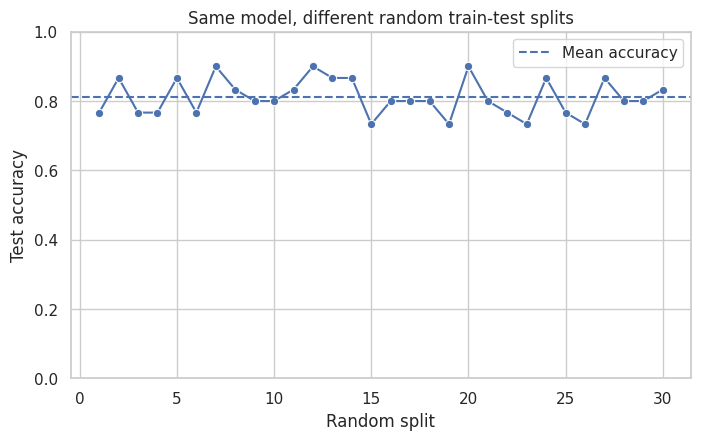

,test_accuracy
count,30.000
mean,0.811
std,0.053
min,0.733
25%,0.767
50%,0.800
75%,0.867
max,0.900


In [6]:
split_results = []
for seed in range(1, 31):
    X_tr, X_te, y_tr, y_te = train_test_split(X_toy, y_toy, test_size=0.25, random_state=seed, stratify=y_toy)
    m = LogisticRegression().fit(X_tr, y_tr)
    split_results.append({"split_seed": seed, "test_accuracy": accuracy_score(y_te, m.predict(X_te))})
split_results_df = pd.DataFrame(split_results)

plt.figure(figsize=(8, 4.5))
sns.lineplot(data=split_results_df, x="split_seed", y="test_accuracy", marker="o")
plt.axhline(split_results_df["test_accuracy"].mean(), linestyle="--", label="Mean accuracy")
plt.title("Same model, different random train-test splits")
plt.xlabel("Random split"); plt.ylabel("Test accuracy"); plt.ylim(0, 1); plt.legend(); plt.show()
split_results_df["test_accuracy"].describe().to_frame().round(3)

**Interpretation.** The score moves because the split changes. Cross-validation reduces reliance on one lucky or unlucky split.

## 4. K-Fold Cross Validation

K-Fold Cross Validation divides the data into K folds. Each fold becomes validation data once, while the remaining folds are used for training.

The mean score estimates typical performance. The standard deviation indicates stability.

Fold scores: [0.875 0.708 0.875 0.833 0.75 ]
Mean accuracy: 0.808
Std accuracy: 0.068


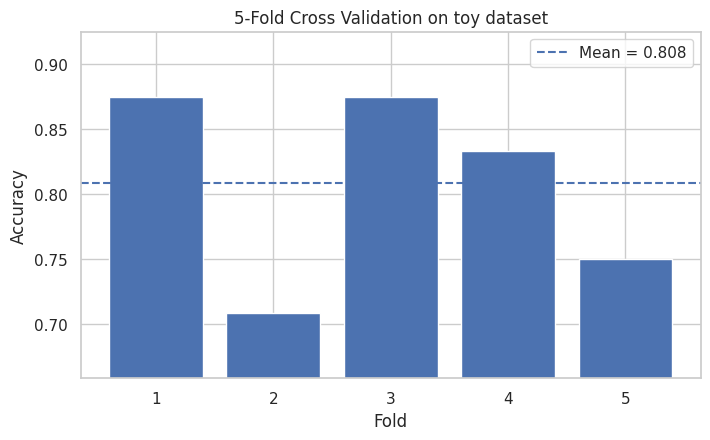

In [7]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
kfold_scores = cross_val_score(LogisticRegression(), X_toy, y_toy, cv=kfold, scoring="accuracy")
print("Fold scores:", np.round(kfold_scores, 3))
print("Mean accuracy:", round(kfold_scores.mean(), 3))
print("Std accuracy:", round(kfold_scores.std(), 3))
plot_fold_scores(kfold_scores, title="5-Fold Cross Validation on toy dataset", ylabel="Accuracy")

**Interpretation.** A high mean with high variability may be less reliable than a slightly lower but more stable score.

## 5. Stratified K-Fold for classification

For classification, the target distribution matters. Stratified K-Fold keeps approximately the same class ratio in each fold. This is important for imbalanced targets.

In [8]:
X_imb, y_imb = make_classification(n_samples=600, n_features=6, n_informative=4, n_redundant=1, weights=[0.88, 0.12], flip_y=0.02, random_state=RANDOM_STATE)
class_balance = summarize_class_balance(y_imb, label_name="loan_default")
class_balance

,class,count,percent
0,0,519,86.500
1,1,81,13.500


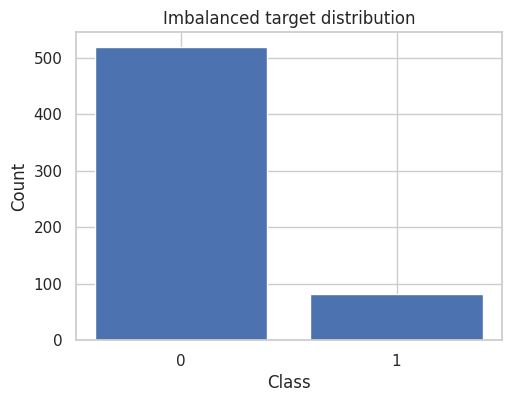

In [9]:
plt.figure(figsize=(5.5, 4))
plt.bar(class_balance["class"].astype(str), class_balance["count"])
plt.title("Imbalanced target distribution")
plt.xlabel("Class"); plt.ylabel("Count"); plt.show()

In [10]:
regular_kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows=[]
for method_name, splitter in [("KFold", regular_kfold), ("StratifiedKFold", stratified_kfold)]:
    for fold, (_, val_idx) in enumerate(splitter.split(X_imb, y_imb), start=1):
        rows.append({"method": method_name, "fold": fold, "positive_class_share": y_imb[val_idx].mean(), "validation_size": len(val_idx)})
fold_balance_df = pd.DataFrame(rows)
fold_balance_df

,method,fold,positive_class_share,validation_size
0,KFold,1,0.150,120
1,KFold,2,0.100,120
2,KFold,3,0.150,120
3,KFold,4,0.167,120
4,KFold,5,0.108,120
5,StratifiedKFold,1,0.133,120
6,StratifiedKFold,2,0.133,120
7,StratifiedKFold,3,0.133,120
8,StratifiedKFold,4,0.133,120
9,StratifiedKFold,5,0.142,120


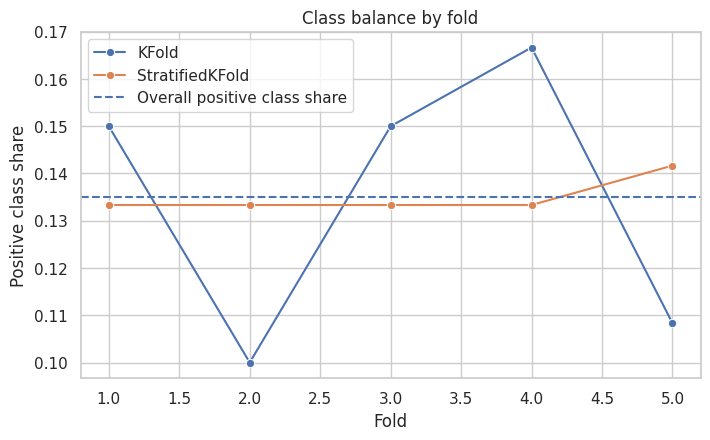

In [11]:
plt.figure(figsize=(8, 4.5))
sns.lineplot(data=fold_balance_df, x="fold", y="positive_class_share", hue="method", marker="o")
plt.axhline(y_imb.mean(), linestyle="--", label="Overall positive class share")
plt.title("Class balance by fold")
plt.xlabel("Fold"); plt.ylabel("Positive class share"); plt.legend(); plt.show()

**Interpretation.** Stratification does not balance the dataset. It preserves the original ratio across splits so each fold resembles the full dataset more closely.

## 6. `cross_val_score()` and scoring

`cross_val_score()` evaluates one metric across folds. The `scoring` argument defines the metric. Accuracy is common, but for imbalanced classification F1, recall, precision, or ROC AUC may be more useful.

In [12]:
cv_model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
scoring_results=[]
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cross_val_score(cv_model, X_imb, y_imb, cv=stratified_kfold, scoring=metric)
    scoring_results.append({"metric": metric, "mean": scores.mean(), "std": scores.std()})
scoring_results_df = pd.DataFrame(scoring_results).round(3)
scoring_results_df

,metric,mean,std
0,accuracy,0.858,0.005
1,precision,0.200,0.400
2,recall,0.012,0.024
3,f1,0.022,0.044
4,roc_auc,0.688,0.046


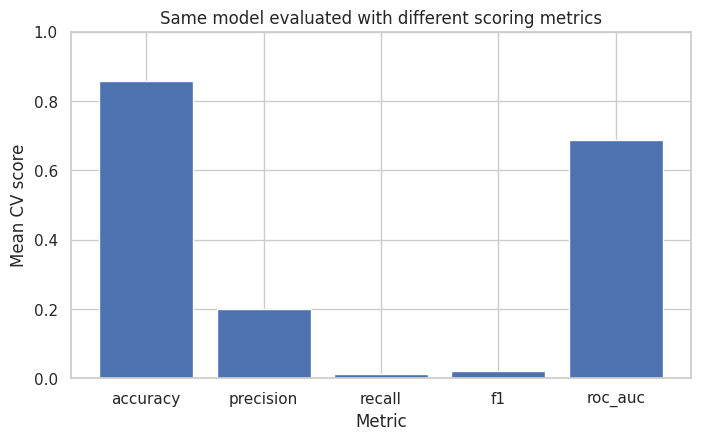

In [13]:
plt.figure(figsize=(8, 4.5))
plt.bar(scoring_results_df["metric"], scoring_results_df["mean"])
plt.title("Same model evaluated with different scoring metrics")
plt.xlabel("Metric"); plt.ylabel("Mean CV score"); plt.ylim(0, 1); plt.show()

**Interpretation.** The same model can look strong under one metric and weaker under another. The metric must match the business cost of mistakes.

## 7. `cross_validate()` for multiple metrics

`cross_validate()` is useful when several metrics should be reviewed together. It can also return training scores, which helps diagnose overfitting.

In [14]:
multi_metric_results = cross_validate(cv_model, X_imb, y_imb, cv=stratified_kfold, scoring=["accuracy", "precision", "recall", "f1", "roc_auc"], return_train_score=True)
multi_metric_df = pd.DataFrame(multi_metric_results)
multi_metric_df.round(3)

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1,test_roc_auc,train_roc_auc
0,0.007,0.015,0.858,0.862,0.000,0.400,0.000,0.031,0.000,0.057,0.745,0.713
1,0.006,0.015,0.858,0.860,0.000,0.333,0.000,0.031,0.000,0.056,0.690,0.722
2,0.006,0.014,0.850,0.869,0.000,0.667,0.000,0.062,0.000,0.113,0.686,0.712
3,0.006,0.015,0.858,0.858,0.000,0.286,0.000,0.031,0.000,0.056,0.715,0.725
4,0.006,0.014,0.867,0.856,1.000,0.000,0.059,0.000,0.111,0.000,0.607,0.723


In [15]:
pd.DataFrame([{"measure": col, "mean": multi_metric_df[col].mean(), "std": multi_metric_df[col].std()} for col in multi_metric_df.columns]).round(3)

,measure,mean,std
0,fit_time,0.006,0.001
1,score_time,0.014,0.000
2,test_accuracy,0.858,0.006
3,train_accuracy,0.861,0.005
4,test_precision,0.200,0.447
5,train_precision,0.337,0.239
6,test_recall,0.012,0.026
7,train_recall,0.031,0.022
8,test_f1,0.022,0.050
9,train_f1,0.056,0.040


**Interpretation.** If training scores are much higher than validation scores, the model may be overfitting.

## 8. Model comparison with cross-validation

Candidate models should be compared using the same cross-validation strategy and the same scoring metric.

In [16]:
candidate_models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}
comparison=[]; fold_rows=[]
for name, model in candidate_models.items():
    scores = cross_val_score(model, X_imb, y_imb, cv=stratified_kfold, scoring="roc_auc")
    comparison.append({"model": name, "mean_roc_auc": scores.mean(), "std_roc_auc": scores.std(), "min_roc_auc": scores.min(), "max_roc_auc": scores.max()})
    for i, score in enumerate(scores, start=1):
        fold_rows.append({"model": name, "fold": i, "roc_auc": score})
comparison_df = pd.DataFrame(comparison).sort_values("mean_roc_auc", ascending=False)
comparison_df.round(3)

,model,mean_roc_auc,std_roc_auc,min_roc_auc,max_roc_auc
2,Random Forest,0.877,0.060,0.799,0.951
0,Logistic Regression,0.688,0.046,0.607,0.745
1,Decision Tree,0.681,0.103,0.545,0.845


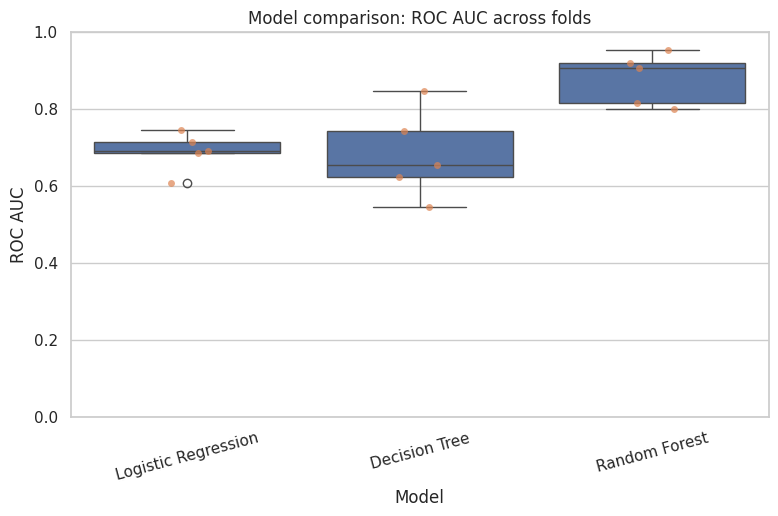

In [17]:
fold_scores_df = pd.DataFrame(fold_rows)
plt.figure(figsize=(9, 5))
sns.boxplot(data=fold_scores_df, x="model", y="roc_auc")
sns.stripplot(data=fold_scores_df, x="model", y="roc_auc", jitter=True, alpha=0.7)
plt.title("Model comparison: ROC AUC across folds")
plt.xlabel("Model"); plt.ylabel("ROC AUC"); plt.ylim(0, 1); plt.xticks(rotation=15); plt.show()

**Interpretation.** The best model is not only the model with the highest mean score. Stability matters for business confidence.

## 9. Train-validation-test workflow

A train-validation-test split separates three roles: train to fit, validation to compare or tune, and test for final independent evaluation.

In [18]:
X_temp, X_final_test, y_temp, y_final_test = train_test_split(X_imb, y_imb, test_size=0.20, random_state=RANDOM_STATE, stratify=y_imb)
X_train, X_validation, y_train, y_validation = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)
split_sizes = pd.DataFrame({"dataset": ["Train", "Validation", "Final test"], "records": [len(y_train), len(y_validation), len(y_final_test)], "positive_class_share": [y_train.mean(), y_validation.mean(), y_final_test.mean()]})
split_sizes.round(3)

,dataset,records,positive_class_share
0,Train,360,0.136
1,Validation,120,0.133
2,Final test,120,0.133


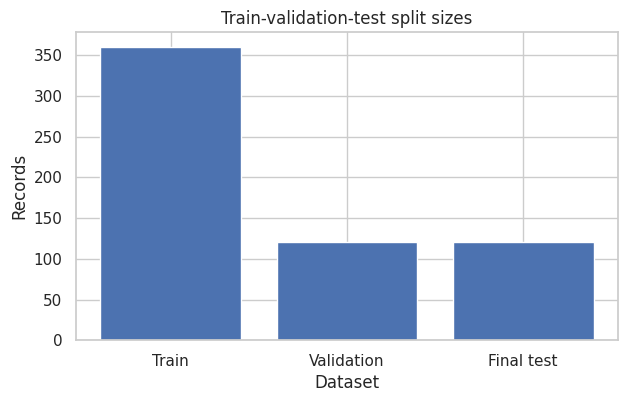

In [19]:
plt.figure(figsize=(7, 4))
plt.bar(split_sizes["dataset"], split_sizes["records"])
plt.title("Train-validation-test split sizes")
plt.xlabel("Dataset"); plt.ylabel("Records"); plt.show()

In [20]:
validation_results=[]
for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_validation)[:, 1]
    pred = model.predict(X_validation)
    validation_results.append({"model": name, "validation_roc_auc": roc_auc_score(y_validation, prob), "validation_f1": f1_score(y_validation, pred), "validation_recall": recall_score(y_validation, pred)})
validation_results_df = pd.DataFrame(validation_results).sort_values("validation_roc_auc", ascending=False)
validation_results_df.round(3)

,model,validation_roc_auc,validation_f1,validation_recall
2,Random Forest,0.728,0.455,0.312
1,Decision Tree,0.715,0.560,0.438
0,Logistic Regression,0.590,0.111,0.062


In [21]:
best_model_name = validation_results_df.iloc[0]["model"]
best_model = candidate_models[best_model_name]
best_model.fit(X_temp, y_temp)
final_prob = best_model.predict_proba(X_final_test)[:, 1]
final_pred = best_model.predict(X_final_test)
pd.DataFrame([{
    "selected_model": best_model_name,
    "final_test_accuracy": accuracy_score(y_final_test, final_pred),
    "final_test_precision": precision_score(y_final_test, final_pred, zero_division=0),
    "final_test_recall": recall_score(y_final_test, final_pred, zero_division=0),
    "final_test_f1": f1_score(y_final_test, final_pred, zero_division=0),
    "final_test_roc_auc": roc_auc_score(y_final_test, final_prob),
}]).round(3)

,selected_model,final_test_accuracy,final_test_precision,final_test_recall,final_test_f1,final_test_roc_auc
0,Random Forest,0.933,1.000,0.500,0.667,0.892


**Interpretation.** The validation set supports model choice. The final test set estimates performance on genuinely unseen data.

## 10. Hyperparameter tuning with cross-validation

`GridSearchCV` evaluates multiple parameter combinations using cross-validation. A final holdout test set is still useful after tuning.

In [22]:
X_train_cv, X_test_holdout, y_train_cv, y_test_holdout = train_test_split(X_imb, y_imb, test_size=0.20, random_state=RANDOM_STATE, stratify=y_imb)
parameter_grid = {"n_estimators": [50, 100], "max_depth": [3, 5, None], "min_samples_leaf": [1, 5]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), parameter_grid, cv=stratified_kfold, scoring="roc_auc", n_jobs=1)
grid_search.fit(X_train_cv, y_train_cv)
print("Best parameters:", grid_search.best_params_)
print("Best mean CV ROC AUC:", round(grid_search.best_score_, 3))

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best mean CV ROC AUC: 0.875


In [23]:
cv_results_df = pd.DataFrame(grid_search.cv_results_)
cv_results_df[["param_n_estimators", "param_max_depth", "param_min_samples_leaf", "mean_test_score", "std_test_score", "rank_test_score"]].sort_values("rank_test_score").head(10).round(3)

,param_n_estimators,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score,rank_test_score
9,100,None,1,0.875,0.059,1
8,50,None,1,0.872,0.048,2
11,100,None,5,0.865,0.049,3
10,50,None,5,0.861,0.051,4
7,100,5,5,0.859,0.054,5
5,100,5,1,0.859,0.058,5
4,50,5,1,0.856,0.051,7
6,50,5,5,0.850,0.053,8
3,100,3,5,0.825,0.031,9
0,50,3,1,0.823,0.031,10


In [24]:
best_tuned_model = grid_search.best_estimator_
y_holdout_pred = best_tuned_model.predict(X_test_holdout)
y_holdout_prob = best_tuned_model.predict_proba(X_test_holdout)[:, 1]
pd.DataFrame([{"accuracy": accuracy_score(y_test_holdout, y_holdout_pred), "precision": precision_score(y_test_holdout, y_holdout_pred, zero_division=0), "recall": recall_score(y_test_holdout, y_holdout_pred, zero_division=0), "f1": f1_score(y_test_holdout, y_holdout_pred, zero_division=0), "roc_auc": roc_auc_score(y_test_holdout, y_holdout_prob)}]).round(3)

,accuracy,precision,recall,f1,roc_auc
0,0.933,1.000,0.500,0.667,0.892


**Interpretation.** Cross-validated tuning reduces the risk of choosing parameters based on one lucky split.

## 11. Leakage-aware preprocessing with pipelines

A common mistake is scaling, imputing, or selecting features using the full dataset before cross-validation. A `Pipeline` fits preprocessing inside each training fold only.

In [25]:
leakage_safe_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
safe_scores = cross_val_score(leakage_safe_pipeline, X_imb, y_imb, cv=stratified_kfold, scoring="roc_auc")
print("Leakage-safe pipeline ROC AUC scores:", np.round(safe_scores, 3))
print("Mean ROC AUC:", round(safe_scores.mean(), 3))
print("Std ROC AUC:", round(safe_scores.std(), 3))

Leakage-safe pipeline ROC AUC scores: [0.745 0.69  0.686 0.715 0.607]
Mean ROC AUC: 0.688
Std ROC AUC: 0.046


**Interpretation.** The pipeline mirrors future production use: preprocessing is learned from available training data and then applied to unseen records.

## 12. Realistic built-in dataset example: breast cancer classification

This example uses a built-in binary classification dataset. The workflow checks target balance, reserves a final test set, compares models with cross-validation, tunes one model, and evaluates the final selected model.

In [26]:
cancer = load_breast_cancer(as_frame=True)
cancer_df = cancer.frame.copy()
# Original target: 0 = malignant, 1 = benign. Create positive class: 1 = malignant risk.
cancer_df["malignant_risk"] = (cancer_df["target"] == 0).astype(int)
cancer_df = cancer_df.drop(columns="target")
print("Shape:", cancer_df.shape)
cancer_df.head()

Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant_risk
0,17.990,10.380,122.800,"1,001.000",0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,"2,019.000",0.162,0.666,0.712,0.265,0.460,0.119,1
1,20.570,17.770,132.900,"1,326.000",0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,"1,956.000",0.124,0.187,0.242,0.186,0.275,0.089,1
2,19.690,21.250,130.000,"1,203.000",0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,"1,709.000",0.144,0.424,0.450,0.243,0.361,0.088,1
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,1
4,20.290,14.340,135.100,"1,297.000",0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,"1,575.000",0.137,0.205,0.400,0.163,0.236,0.077,1


In [27]:
cancer_balance = summarize_class_balance(cancer_df["malignant_risk"], label_name="malignant_risk")
cancer_balance

,class,count,percent
0,0,357,62.740
1,1,212,37.260


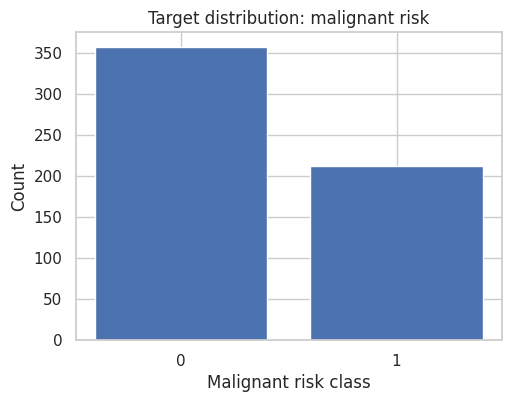

In [28]:
plt.figure(figsize=(5.5, 4))
plt.bar(cancer_balance["class"].astype(str), cancer_balance["count"])
plt.title("Target distribution: malignant risk")
plt.xlabel("Malignant risk class"); plt.ylabel("Count"); plt.show()

In [29]:
X_cancer = cancer_df.drop(columns="malignant_risk")
y_cancer = cancer_df["malignant_risk"]
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(X_cancer, y_cancer, test_size=0.25, random_state=RANDOM_STATE, stratify=y_cancer)
print("Training shape:", X_train_cancer.shape)
print("Test shape:", X_test_cancer.shape)

Training shape: (426, 30)
Test shape: (143, 30)


In [30]:
cancer_models = {
    "Logistic Regression": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}
cancer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows=[]
for name, model in cancer_models.items():
    scores = cross_val_score(model, X_train_cancer, y_train_cancer, cv=cancer_cv, scoring="roc_auc")
    rows.append({"model": name, "mean_cv_roc_auc": scores.mean(), "std_cv_roc_auc": scores.std()})
cancer_comparison_df = pd.DataFrame(rows).sort_values("mean_cv_roc_auc", ascending=False)
cancer_comparison_df.round(3)

,model,mean_cv_roc_auc,std_cv_roc_auc
0,Logistic Regression,0.991,0.009
2,Random Forest,0.988,0.011
1,Decision Tree,0.916,0.031


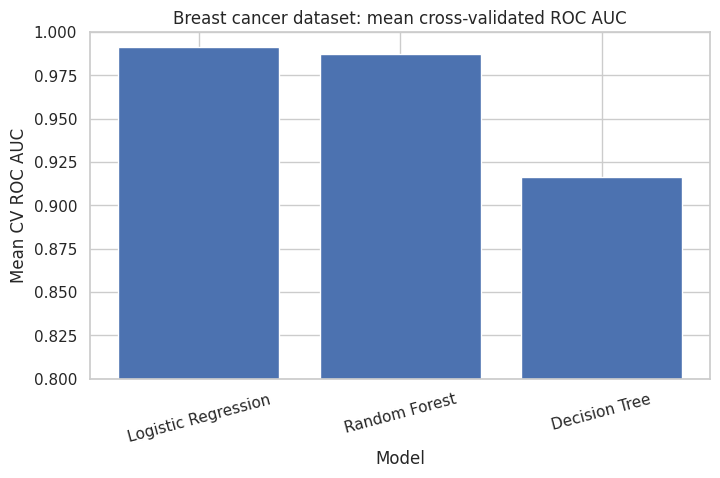

In [31]:
plt.figure(figsize=(8, 4.5))
plt.bar(cancer_comparison_df["model"], cancer_comparison_df["mean_cv_roc_auc"])
plt.title("Breast cancer dataset: mean cross-validated ROC AUC")
plt.xlabel("Model"); plt.ylabel("Mean CV ROC AUC"); plt.ylim(0.8, 1.0); plt.xticks(rotation=15); plt.show()

In [32]:
logistic_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
logistic_grid = {"model__C": [0.01, 0.1, 1, 10, 100], "model__penalty": ["l2"]}
logistic_search = GridSearchCV(logistic_pipeline, logistic_grid, cv=cancer_cv, scoring="roc_auc", n_jobs=1)
logistic_search.fit(X_train_cancer, y_train_cancer)
print("Best parameters:", logistic_search.best_params_)
print("Best CV ROC AUC:", round(logistic_search.best_score_, 3))

Best parameters: {'model__C': 0.1, 'model__penalty': 'l2'}
Best CV ROC AUC: 0.992


In [33]:
final_cancer_model = logistic_search.best_estimator_
y_cancer_pred = final_cancer_model.predict(X_test_cancer)
y_cancer_prob = final_cancer_model.predict_proba(X_test_cancer)[:, 1]
final_cancer_metrics = pd.DataFrame([{"accuracy": accuracy_score(y_test_cancer, y_cancer_pred), "precision": precision_score(y_test_cancer, y_cancer_pred, zero_division=0), "recall": recall_score(y_test_cancer, y_cancer_pred, zero_division=0), "f1": f1_score(y_test_cancer, y_cancer_pred, zero_division=0), "roc_auc": roc_auc_score(y_test_cancer, y_cancer_prob)}])
final_cancer_metrics.round(3)

,accuracy,precision,recall,f1,roc_auc
0,0.979,1.000,0.943,0.971,0.998


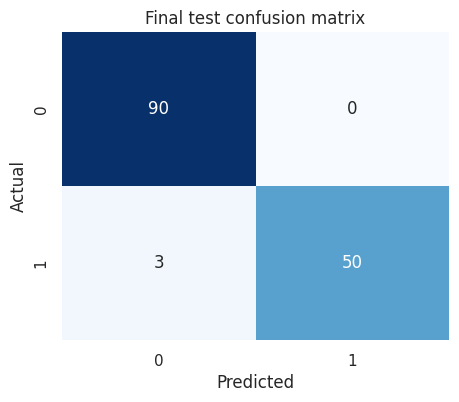

                    precision    recall  f1-score   support

not malignant risk       0.97      1.00      0.98        90
    malignant risk       1.00      0.94      0.97        53

          accuracy                           0.98       143
         macro avg       0.98      0.97      0.98       143
      weighted avg       0.98      0.98      0.98       143



In [34]:
cm = confusion_matrix(y_test_cancer, y_cancer_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Final test confusion matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()
print(classification_report(y_test_cancer, y_cancer_pred, target_names=["not malignant risk", "malignant risk"]))

**Business/data mining interpretation.** Cross-validation supports model selection before final test evaluation. In a medical-style classification setting, recall for the risk class may be especially important because missing a true risk case can be more costly than raising a false alarm.

## 13. Optional: validation curve for model complexity

Validation curves show how model performance changes as a hyperparameter changes. This example changes the maximum depth of a decision tree.

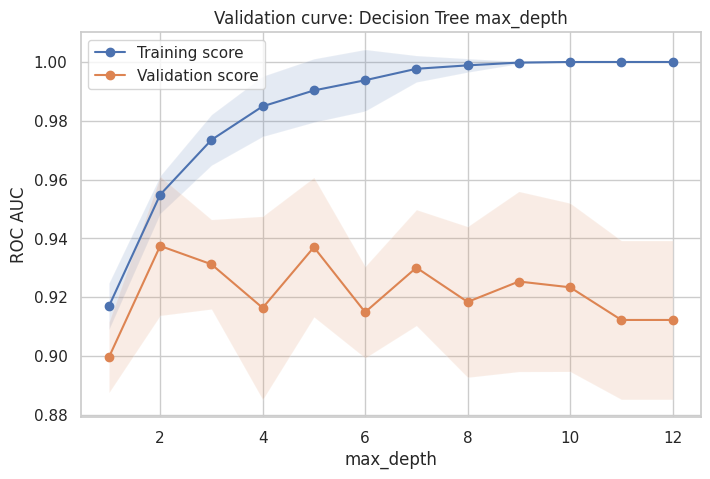

In [35]:
depth_values = np.arange(1, 13)
train_scores, validation_scores = validation_curve(DecisionTreeClassifier(random_state=RANDOM_STATE), X_train_cancer, y_train_cancer, param_name="max_depth", param_range=depth_values, cv=cancer_cv, scoring="roc_auc")
train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
validation_mean, validation_std = validation_scores.mean(axis=1), validation_scores.std(axis=1)
plt.figure(figsize=(8, 5))
plt.plot(depth_values, train_mean, marker="o", label="Training score")
plt.plot(depth_values, validation_mean, marker="o", label="Validation score")
plt.fill_between(depth_values, train_mean-train_std, train_mean+train_std, alpha=0.15)
plt.fill_between(depth_values, validation_mean-validation_std, validation_mean+validation_std, alpha=0.15)
plt.title("Validation curve: Decision Tree max_depth")
plt.xlabel("max_depth"); plt.ylabel("ROC AUC"); plt.legend(); plt.show()

**Interpretation.** When training performance keeps improving but validation performance flattens or decreases, overfitting is likely.

## 14. Synthetic dataset generator script

A separate script is included with this notebook:

`generate_cross_validation_dataset.py`

It creates a business-style synthetic loan-default dataset with an imbalanced target and realistic feature names. Run it from a terminal with:

```bash
python generate_cross_validation_dataset.py
```

The script writes `data/cross_validation_synthetic_loan_default.csv`.

In [36]:
X_syn, y_syn = make_classification(n_samples=1200, n_features=6, n_informative=4, n_redundant=1, weights=[0.78, 0.22], class_sep=1.05, flip_y=0.04, random_state=RANDOM_STATE)
synthetic_df = pd.DataFrame(X_syn, columns=["income_index", "debt_ratio_index", "payment_history_index", "savings_index", "credit_usage_index", "application_complexity_index"])
synthetic_df["loan_default"] = y_syn
synthetic_df.head()

,income_index,debt_ratio_index,payment_history_index,savings_index,credit_usage_index,application_complexity_index,loan_default
0,1.938,-1.355,-1.422,-0.431,-2.273,-2.734,0
1,-1.963,0.645,-0.270,1.312,2.868,-1.362,0
2,0.790,1.309,-1.098,0.077,-1.112,0.436,0
3,0.049,-1.015,-1.250,-1.092,-1.175,-1.607,0
4,1.165,-1.683,0.605,0.066,0.160,-1.522,0


In [37]:
X_synthetic = synthetic_df.drop(columns="loan_default")
y_synthetic = synthetic_df["loan_default"]
synthetic_pipeline = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
synthetic_scores = cross_val_score(synthetic_pipeline, X_synthetic, y_synthetic, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), scoring="roc_auc")
cv_summary(synthetic_scores, label="Synthetic loan-default model")

,model,mean_score,std_score,min_score,max_score
0,Synthetic loan-default model,0.760,0.051,0.693,0.833


## 15. Common mistakes and pitfalls

1. **Training and testing on the same data** produces overly optimistic scores.
2. **Using the test set for model selection** contaminates final evaluation.
3. **Ignoring class imbalance** can make accuracy misleading.
4. **Not stratifying classification splits** can create unrepresentative folds.
5. **Preprocessing before splitting or cross-validation** can leak information.
6. **Reporting only the mean score** hides instability.
7. **Comparing models with different folds** makes comparison less fair.